### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [1]:
import tensorflow as tf
tf.set_random_seed(42)
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import keras
from keras.models import Sequential,Input,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers.normalization import BatchNormalization
from keras.layers.advanced_activations import LeakyReLU
from keras.optimizers import SGD

Using TensorFlow backend.


In [2]:
tf.__version__

'1.13.1'

### Collect Data

In [3]:
import keras

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [5]:
print("x_train shape:",X_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


In [6]:
print("x_test shape:", X_test.shape, "y_test shape:", y_test.shape)

x_test shape: (10000, 28, 28) y_test shape: (10000,)


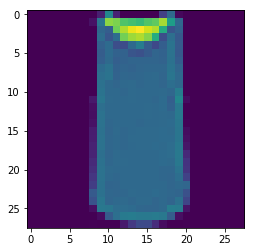

In [7]:
# Show one of the images from the training dataset
img_index=2
plt.imshow(X_train[img_index])

In [8]:
print(y_test[0:5])

[9 2 1 1 6]


convert each 28 x 28 image of the train and test set into a matrix of size 28 x 28 x 1 which is fed into the network.

In [9]:
X_train = X_train.reshape(-1, 28,28, 1)
X_test = X_test.reshape(-1, 28,28, 1)
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

he data right now is in an int8 format, so before you feed it into the network you need to convert its type to float32

In [10]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [38]:
# Change the labels from categorical to one-hot encoding
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)
#Display the change for category label using one-hot encoding
print('Original label:', y_train[0])
print('After conversion to one-hot:', y_train_one_hot[0])

Original label: 9
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [12]:
print(y_train.shape)
print('First 5 examples now are: ', y_train[0:5])

(60000,)
First 5 examples now are:  [9 0 0 3 0]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

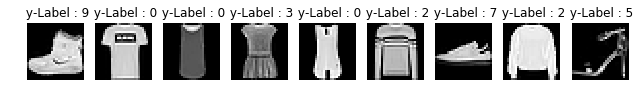

In [13]:
plt.figure(figsize = (12,2))
for i in range(1,10):
    plt.subplot(1,10,i)    
    plt.imshow(X_train[i-1].reshape(28,28), cmap='gray', interpolation='nearest')
    plt.axis('off')
    plt.title(" y-Label : {}".format(y_train[i-1]))
    # plt.tight_layout()

In [14]:
print("Number of train data - " + str(len(X_train)))
print("Number of test data - " + str(len(X_test)))

Number of train data - 60000
Number of test data - 10000


In [15]:
# Find the unique numbers from the train labels
classes = np.unique(y_train)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]


### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [16]:
# Split the data set into training and testing
X_traini, X_testi, y_traini, y_testi = train_test_split(X_train, y_train_one_hot, test_size=0.2, random_state=7)

In [17]:
X_traini.shape,X_testi.shape,y_traini.shape,y_testi.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000, 10), (12000, 10))

In [18]:
model = Sequential()
model.add(Conv2D(1, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.sgd(),metrics=['accuracy'])

Instructions for updating:
Colocations handled automatically by placer.


In [19]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 28, 28, 1)         10        
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 1)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 196)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1970      
Total params: 1,980
Trainable params: 1,980
Non-trainable params: 0
_________________________________________________________________


### Execute the model using model.fit()

In [21]:
# Fit the model
model.fit(X_traini, y_traini, epochs=5, batch_size=5)

Epoch 1/5
48000/48000 [==============================] - 17s 364us/step - loss: 14.5180 - acc: 0.0993
Epoch 2/5
48000/48000 [==============================] - 18s 371us/step - loss: 14.5180 - acc: 0.0993
Epoch 3/5
48000/48000 [==============================] - 18s 367us/step - loss: 14.5180 - acc: 0.0993
Epoch 4/5
48000/48000 [==============================] - 18s 371us/step - loss: 14.5180 - acc: 0.0993
Epoch 5/5
48000/48000 [==============================] - 19s 403us/step - loss: 14.5180 - acc: 0.0993


In [22]:
# Fit the model
model.fit(X_train, y_train_one_hot, epochs=5, batch_size=5)

Epoch 1/5
60000/60000 [==============================] - 21s 354us/step - loss: 14.5063 - acc: 0.1000
Epoch 2/5
60000/60000 [==============================] - 22s 364us/step - loss: 14.5063 - acc: 0.1000
Epoch 3/5
60000/60000 [==============================] - 22s 367us/step - loss: 14.5063 - acc: 0.1000
Epoch 4/5
60000/60000 [==============================] - 22s 368us/step - loss: 14.5063 - acc: 0.1000
Epoch 5/5
60000/60000 [==============================] - 22s 373us/step - loss: 14.5063 - acc: 0.1000


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [23]:
X_train = X_train / 255.
X_test = X_test / 255.

### Execute the model

In [25]:
# Fit the model
model.fit(X_train, y_train_one_hot, epochs=5, batch_size=5)

Epoch 1/5
60000/60000 [==============================] - 22s 363us/step - loss: 14.5063 - acc: 0.1000
Epoch 2/5
60000/60000 [==============================] - 23s 389us/step - loss: 14.5063 - acc: 0.1000
Epoch 3/5
60000/60000 [==============================] - 24s 395us/step - loss: 14.5063 - acc: 0.1000
Epoch 4/5
60000/60000 [==============================] - 22s 367us/step - loss: 14.5063 - acc: 0.1000
Epoch 5/5
60000/60000 [==============================] - 22s 369us/step - loss: 14.5063 - acc: 0.1000


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [31]:
model_sgdo1 = Sequential()
model_sgdo1.add(Conv2D(1, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model_sgdo1.add(MaxPooling2D((2, 2)))
model_sgdo1.add(Flatten())
model_sgdo1.add(Dense(10, activation='softmax'))
opt = SGD(lr=0.001, momentum=0.9)
model_sgdo1.compile(loss=keras.losses.categorical_crossentropy, optimizer=opt,metrics=['accuracy'])

In [32]:
# Fit the model
model_sgdo1.fit(X_train, y_train_one_hot, epochs=5, batch_size=5)

Epoch 1/5
60000/60000 [==============================] - 22s 360us/step - loss: 0.5801 - acc: 0.7949
Epoch 2/5
60000/60000 [==============================] - 21s 353us/step - loss: 0.4833 - acc: 0.8286
Epoch 3/5
60000/60000 [==============================] - 22s 359us/step - loss: 0.4674 - acc: 0.8348
Epoch 4/5
60000/60000 [==============================] - 21s 358us/step - loss: 0.4578 - acc: 0.8378
Epoch 5/5
60000/60000 [==============================] - 21s 353us/step - loss: 0.4519 - acc: 0.8411


### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [33]:
model_sgdo2 = Sequential()
model_sgdo2.add(Conv2D(100, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model_sgdo2.add(Dense(100, activation='softmax'))
model_sgdo2.add(MaxPooling2D((2, 2)))
model_sgdo2.add(Flatten())
model_sgdo2.add(Dense(10, activation='softmax'))
opt = SGD(lr=0.03, momentum=0.9)
model_sgdo2.compile(loss=keras.losses.categorical_crossentropy, optimizer=opt,metrics=['accuracy'])

In [34]:
# Fit the model
model_sgdo2.fit(X_train, y_train_one_hot, epochs=5, batch_size=5)

Instructions for updating:
Deprecated in favor of operator or tf.math.divide.
Epoch 1/5
60000/60000 [==============================] - 465s 8ms/step - loss: 0.5737 - acc: 0.8016
Epoch 2/5
60000/60000 [==============================] - 497s 8ms/step - loss: 0.3880 - acc: 0.8668
Epoch 3/5
60000/60000 [==============================] - 529s 9ms/step - loss: 0.3429 - acc: 0.8812
Epoch 4/5
60000/60000 [==============================] - 578s 10ms/step - loss: 0.3164 - acc: 0.8883
Epoch 5/5
60000/60000 [==============================] - 616s 10ms/step - loss: 0.2945 - acc: 0.8984


## Review model

In [39]:
test_eval = model_sgdo2.evaluate(X_test, y_test_one_hot, verbose=0)

In [47]:
print('Test loss: ', test_eval[0])
print('Test accuracy:  % 5.2f' % (test_eval[1]*100) ,'%' )

Test loss: 0.3597107204437256
Test accuracy:   88.26 %


### Run the model

In [51]:
model_ad = Sequential()
model_ad.add(Conv2D(32, kernel_size=(3, 3),activation='linear',input_shape=(28,28,1),padding='same'))
model_ad.add(Dense(100, activation='softmax'))
model_ad.add(MaxPooling2D((2, 2)))
model_ad.add(Flatten())
model_ad.add(Dense(10, activation='softmax'))
model_ad.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])

In [52]:
# Fit the model
model_ad.fit(X_train, y_train_one_hot, epochs=1, batch_size=5)

Epoch 1/1
60000/60000 [==============================] - 373s 6ms/step - loss: 0.4422 - acc: 0.8401


In [53]:
model_ad1 = Sequential()
model_ad1.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model_ad1.add(MaxPooling2D((2, 2)))
model_ad1.add(Flatten())
model_ad1.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model_ad1.add(Dense(10, activation='softmax'))
# compile model
opt = SGD(lr=0.01, momentum=0.9)
model_ad1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [57]:
# Fit the model
model_ad1.fit(X_train, y_train_one_hot, epochs=50, batch_size=256)

Epoch 1/50
60000/60000 [==============================] - 19s 311us/step - loss: 0.1857 - acc: 0.9309
Epoch 2/50
60000/60000 [==============================] - 22s 368us/step - loss: 0.1813 - acc: 0.9330
Epoch 3/50
60000/60000 [==============================] - 23s 376us/step - loss: 0.1776 - acc: 0.9346
Epoch 4/50
60000/60000 [==============================] - 23s 391us/step - loss: 0.1739 - acc: 0.9364
Epoch 5/50
60000/60000 [==============================] - 23s 383us/step - loss: 0.1708 - acc: 0.9367
Epoch 6/50
60000/60000 [==============================] - 22s 372us/step - loss: 0.1679 - acc: 0.9386
Epoch 7/50
60000/60000 [==============================] - 23s 376us/step - loss: 0.1650 - acc: 0.9400
Epoch 8/50
60000/60000 [==============================] - 23s 390us/step - loss: 0.1616 - acc: 0.9407
Epoch 9/50
60000/60000 [==============================] - 25s 411us/step - loss: 0.1587 - acc: 0.9422
Epoch 10/50
60000/60000 [==============================] - 22s 374us/step - loss: 

In [58]:
model_ad2 = Sequential()
model_ad2.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model_ad2.add(MaxPooling2D((2, 2)))
model_ad2.add(Flatten())
model_ad2.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model_ad2.add(Dense(10, activation='softmax'))
# compile model
opt = SGD(lr=0.04, momentum=0.9)
model_ad2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [59]:
# Fit the model
model_ad2.fit(X_train, y_train_one_hot, epochs=100, batch_size=256)

Epoch 1/100
60000/60000 [==============================] - 22s 360us/step - loss: 0.5486 - acc: 0.8100
Epoch 2/100
60000/60000 [==============================] - 25s 409us/step - loss: 0.3099 - acc: 0.8891
Epoch 3/100
60000/60000 [==============================] - 25s 424us/step - loss: 0.2687 - acc: 0.9046
Epoch 4/100
60000/60000 [==============================] - 25s 419us/step - loss: 0.2457 - acc: 0.9104
Epoch 5/100
60000/60000 [==============================] - 24s 408us/step - loss: 0.2205 - acc: 0.9199
Epoch 6/100
60000/60000 [==============================] - 25s 421us/step - loss: 0.2096 - acc: 0.9231
Epoch 7/100
60000/60000 [==============================] - 26s 439us/step - loss: 0.1906 - acc: 0.9302
Epoch 8/100
60000/60000 [==============================] - 27s 453us/step - loss: 0.1771 - acc: 0.9357
Epoch 9/100
60000/60000 [==============================] - 25s 420us/step - loss: 0.1676 - acc: 0.9393
Epoch 10/100
60000/60000 [==============================] - 26s 427us/ste

60000/60000 [==============================] - 25s 420us/step - loss: 4.4721e-04 - acc: 1.0000
Epoch 79/100
60000/60000 [==============================] - 26s 426us/step - loss: 4.4058e-04 - acc: 1.0000
Epoch 80/100
60000/60000 [==============================] - 26s 441us/step - loss: 4.2768e-04 - acc: 1.0000
Epoch 81/100
60000/60000 [==============================] - 26s 437us/step - loss: 4.1563e-04 - acc: 1.0000
Epoch 82/100
60000/60000 [==============================] - 24s 405us/step - loss: 4.0876e-04 - acc: 1.0000
Epoch 83/100
60000/60000 [==============================] - 24s 405us/step - loss: 3.9861e-04 - acc: 1.0000
Epoch 84/100
60000/60000 [==============================] - 24s 394us/step - loss: 3.9005e-04 - acc: 1.0000
Epoch 85/100
60000/60000 [==============================] - 23s 390us/step - loss: 3.7951e-04 - acc: 1.0000
Epoch 86/100
60000/60000 [==============================] - 24s 403us/step - loss: 3.7421e-04 - acc: 1.0000
Epoch 87/100
60000/60000 [===============

In [60]:
#It is overfit?

In [61]:
test_eval1 = model_ad2.evaluate(X_test, y_test_one_hot, verbose=0)

In [62]:
print('Test loss: ', test_eval1[0])
print('Test accuracy:  % 5.2f' % (test_eval1[1]*100) ,'%' )

Test loss:  0.6021676274558995
Test accuracy:   91.63 %
